This code runs through the first 4 steps of the GIBF algorithm as laid out in the mathematical roadmap.

1) **Generate CSDM** — two cells are provided: one using `scipy.signal.csd` (correct but slow) and one manual STFT-based implementation (fast but not yet validated). Run the scipy cell for reliable results.

2) **Select the number of eigenmodes (MDL/AIC)** — automated with Wax & Kailath (1985) information-theoretic criteria. For each of the 513 frequency bins, the MDL criterion searches over a single integer k (model order) to find where the remaining eigenvalues look like noise. This replaces the old hardcoded k=13. Output is `coherent_eigenmodes` shaped `(513, 87, k*)` where k* is the MDL maximum across bins, and `coherent_eigenmodes_mdl` (ragged list) where each entry is `(87, k_f)` for the bin-specific order.

3) **Construct the transfer matrix A** — vibe coded, returns the correct shape. This is possibly the most important cell as it encodes the geometry of the sensors, the resolution of the map, and the field physics.

4) **Ridge regression to create Q_blurry** — retaining MDL-selected eigenmodes makes this significantly faster than the old all-13 approach. Alpha must still be tuned.

**Next steps:** \
5) Iteratively reweighted least squares \
6) Reduce dimensionality of A as we iterate \
7) Repeat until convergence or a set iteration count \
8) Create final source map

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal

# This cell loads the data into an array like this:  sensor_i = [x_i, y_i, z_i], mag_data = [sensor_1, ..., sensor_m ]
# 27 Sensors x 3 time series gives 87 columns. Each time series has 7201 points so there are 7201 rows

np.set_printoptions(precision=2, suppress=True) # no more ugly decimals

folder_path = "C:\\Users\\shane\\Desktop\\Research Based Coding\\IBF\\Mag Data" # Copy your path to the data here
folder = Path(folder_path)
text_files = sorted(folder.glob("*.txt"))

all_columns = []

for file_path in text_files:
    # Load the three time series columns
    data = np.loadtxt(file_path, usecols=(7, 8, 9))
    
    # Add each column individually
    all_columns.append(data[:, 0])
    all_columns.append(data[:, 1])
    all_columns.append(data[:, 2])

# Stack all columns
mag_data = np.column_stack(all_columns)

print(f"✓ Loaded {mag_data.shape[0]} rows × {mag_data.shape[1]} columns")
print(f"\nFirst 5 rows (preview):")
print(mag_data[:5, :5])

✓ Loaded 7201 rows × 87 columns

First 5 rows (preview):
[[  -13.26    43.12   -20.89 15632.25   621.09]
 [  -13.27    43.11   -20.86 15632.92   621.64]
 [  -13.3     43.11   -20.9  15632.72   621.4 ]
 [  -13.3     43.07   -20.89 15632.22   621.55]
 [  -13.32    43.09   -20.85 15632.58   621.15]]


In [5]:
# Compute CSDM manually by taking the STFT and the outer product using eigensum for efficiency
# This method would be preferable to scipy`s signal.csd() but we need to make sure it is calculating it properly (it is not)

# --- Configuration ---
fs = 1.0        # Sampling frequency
nperseg = 1024  # Segment length
noverlap = nperseg//2  # 50% overlap

# --- Step 1: Compute STFT for all 87 channels at once ---
# mag_data shape: (7201, 87)
# axis=0 computes the STFT along the time dimension for each sensor
frequencies, times, stft_data = signal.stft(
    mag_data, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap, 
    axis=0,
    detrend='constant',  # Add detrending to match csd()
    boundary=None
)

# Calculate window correction factor
window = signal.get_window('hann', nperseg)
window_correction = np.sum(window**2)  # For power spectra

# Output data shape: (513, 87, 14) 
# (513 frequency bins, 87 sensors, 14 time segments)
print("stft_data shape:", stft_data.shape)                     
print("Number of frequency bins:", frequencies.shape) 
print("Number of time segments:", times.shape) 

# --- Step 2: Compute CSDM using Einstein Summation ---
# 'f_t' represents (frequencies, sensors, time_segments)
# We multiply the sensor vectors and average over the time segments (t)
csdm_manual = np.einsum('fit,fjt->fij', stft_data, np.conj(stft_data), optimize=True)
csdm_manual = csdm_manual / (fs * times.shape[0] * window_correction) 

# --- Final Shape Check ---
print("CSDM shape:", csdm_manual.shape)

stft_data shape: (513, 87, 14)
Number of frequency bins: (513,)
Number of time segments: (14,)
CSDM shape: (513, 87, 87)


In [6]:
# Compute CSDM using scipy`s signal.csd()
# This method is slow but very simple to use

# --- Configuration ---
fs = 1.0  # Sampling frequency
nperseg = 1024  # Segment length
noverlap = nperseg // 2  # 50% overlap is standard

# Reshape arrays to allow NumPy broadcasting to compute all sensor pairs:
# x_input shape becomes: (7201, 87, 1)
# y_input shape becomes: (7201, 1, 87)
x_input = mag_data[:, :, np.newaxis]
y_input = mag_data[:, np.newaxis, :]

# Compute CSDM along the time axis (axis 0)
# SciPy automatically demeans, applies a Hann window, splits into segments, 
# takes the STFT, performs outer products, and takes the expectation (mean)
frequencies, csdm_csd = signal.csd(
    x_input, 
    y_input, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap, 
    axis=0
)

# --- Final Shape Check ---
print("Number of frequncy bins:", frequencies.shape)  # Output: (513,)
print("CSDM shape:", csdm_csd.shape) # Output: (513, 87, 87)

Number of frequncy bins: (513,)
CSDM shape: (513, 87, 87)


In [7]:
# Compute the eigenvalues and eigenvectors of the CSDM, vectorized across all frequency bins.
# eigh() exploits the Hermitian structure and returns real eigenvalues in ascending order.

eigenvalues, eigenvectors = np.linalg.eigh(csdm_csd)

# Sort everything into descending order (largest eigenvalue first)
desc_eigenvalues  = eigenvalues[:, ::-1]                           # (513, 87) real
desc_sqrt_eigenvalues = np.sqrt(np.clip(desc_eigenvalues, 0, None))  # (513, 87)
desc_eigenvectors = eigenvectors[:, :, ::-1]                       # (513, 87, 87)

# Scale each eigenvector by its square-root eigenvalue to form eigenmodes
# Shape: (513, 87, 87)
eigenmodes = desc_eigenvectors * desc_sqrt_eigenvalues[:, np.newaxis, :]

print("Eigenvalues shape :", eigenvalues.shape)    # (513, 87)
print("Eigenvectors shape:", eigenvectors.shape)   # (513, 87, 87)
print("Eigenmodes shape  :", eigenmodes.shape)     # (513, 87, 87)
print()
print("Model order selection (MDL/AIC) is done in the next cell.")
print("coherent_eigenmodes will be defined there.")

Eigenvalues shape : (513, 87)
Eigenvectors shape: (513, 87, 87)
Eigenmodes shape  : (513, 87, 87)

Model order selection (MDL/AIC) is done in the next cell.
coherent_eigenmodes will be defined there.


In [8]:
# ── Step 2: MDL / AIC Eigenmode Selection ───────────────────────────────────
#
# Problem: which of the non-zero eigenvalues per bin are real signal vs noise?
#
# Key constraint: the STFT-based CSDM has rank ≤ L (number of snapshots = 14),
# so at most L eigenvalues are non-zero. In practice this notebook produces only
# 13 non-zero eigenvalues per bin (due to windowing / detrending). The 14th is a
# structural zero — not noise, just null-space. We must exclude it before running
# MDL or it permanently contaminates the noise model and drives k* to 1.
#
# Solution: detect the number of numerically significant eigenvalues per bin (P_f)
# and run MDL only within that rank-P_f subspace.
#
# Criterion — Wax & Kailath (1985):
#   For each candidate k, test whether the remaining (P_f - k) eigenvalues are
#   equal under a "spherical noise" model. The log-likelihood ratio is:
#
#     LLR(k) = L·(P_f−k)·[ln AM(λ_{k+1}…λ_{P_f}) − ln GM(λ_{k+1}…λ_{P_f})]   ≥ 0
#
#   LLR = 0 iff all remaining eigenvalues are exactly equal (pure noise).
#   Penalising by the free parameters in the k-source model:
#
#     MDL(k) = LLR(k) + ½·k·(2·P_f−k)·ln L    ← conservative, statistically consistent
#     AIC(k) = LLR(k) +   k·(2·P_f−k)          ← lighter penalty, picks more modes

# ── Parameters ───────────────────────────────────────────────────────────────
n_snapshots = stft_data.shape[2]      # L = 14 time segments
M           = desc_eigenvalues.shape[1]  # 87 sensors


def compute_mdl_aic(lam_desc, L):
    """
    MDL and AIC model-order selection for ordered CSDM eigenvalues.

    Parameters
    ----------
    lam_desc : (P,) array  — significant (non-zero) eigenvalues, descending
    L        : int         — number of snapshots used to form the CSDM

    Returns
    -------
    k_mdl : int      — MDL-optimal number of signal eigenmodes
    k_aic : int      — AIC-optimal number of signal eigenmodes
    mdl   : (P-1,)  — MDL criterion values for k = 0 … P-2
    aic   : (P-1,)  — AIC criterion values for k = 0 … P-2
    """
    P   = len(lam_desc)
    lam = np.clip(lam_desc, 1e-30, None)   # guard log(0)

    mdl = np.full(P - 1, np.inf)
    aic = np.full(P - 1, np.inf)

    for k in range(P - 1):               # need ≥ 2 remaining eigenvalues
        noise    = lam[k:]
        n        = len(noise)

        am       = noise.mean()
        gm       = np.exp(np.log(noise).mean())

        llr      = L * n * (np.log(am) - np.log(gm))   # ≥ 0 by AM-GM

        n_params = k * (2 * P - k)       # free parameters for k-source model

        mdl[k]   = llr + 0.5 * n_params * np.log(L)
        aic[k]   = llr + n_params

    return int(np.argmin(mdl)), int(np.argmin(aic)), mdl, aic


# ── Apply per bin, using only the significant (non-zero) eigenvalues ─────────
# Threshold: eigenvalues below 1e-6 × the largest eigenvalue in the bin are
# treated as structural zeros and excluded from the MDL search.
REL_THRESHOLD = 1e-6

k_mdl_all  = np.zeros(513, dtype=int)
k_aic_all  = np.zeros(513, dtype=int)
p_rank_all = np.zeros(513, dtype=int)   # effective rank per bin (for diagnostics)

for f in range(513):
    lam_f     = desc_eigenvalues[f]
    threshold = lam_f[0] * REL_THRESHOLD
    n_sig     = int(np.sum(lam_f > threshold))
    n_sig     = max(n_sig, 2)             # need at least 2 eigenvalues to test
    p_rank_all[f] = n_sig

    k_mdl_all[f], k_aic_all[f], _, _ = compute_mdl_aic(
        lam_f[:n_sig], n_snapshots
    )


# ── Build coherent eigenmode outputs ─────────────────────────────────────────

# Ragged list: coherent_eigenmodes_mdl[f] has shape (87, k_mdl_all[f])
coherent_eigenmodes_mdl = [
    eigenmodes[f, :, : k_mdl_all[f]] for f in range(513)
]

# Fixed-shape array (MDL maximum k) — drop-in for old coherent_eigenmodes[:,:,:13]
k_max_mdl           = int(k_mdl_all.max())
coherent_eigenmodes = eigenmodes[:, :, :k_max_mdl]


# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 58)
print("  MDL / AIC Eigenmode Selection — Results")
print("=" * 58)
print(f"  Snapshots L            : {n_snapshots}")
print(f"  Sensors   M            : {M}")
print(f"  Effective rank P (per bin) — "
      f"min={p_rank_all.min()}, max={p_rank_all.max()}, mean={p_rank_all.mean():.1f}")
print()
print(f"  MDL k*  — min={k_mdl_all.min():2d}, max={k_mdl_all.max():2d}, "
      f"mean={k_mdl_all.mean():.1f}, median={int(np.median(k_mdl_all))}")
print(f"  AIC k*  — min={k_aic_all.min():2d}, max={k_aic_all.max():2d}, "
      f"mean={k_aic_all.mean():.1f}, median={int(np.median(k_aic_all))}")
print()
print(f"  coherent_eigenmodes        : {coherent_eigenmodes.shape}")
print(f"  coherent_eigenmodes_mdl[0] : {coherent_eigenmodes_mdl[0].shape}")
print()

# ── Single-bin diagnostic ─────────────────────────────────────────────────────
f_test    = 200
lam_test  = desc_eigenvalues[f_test]
n_sig_t   = int(np.sum(lam_test > lam_test[0] * REL_THRESHOLD))
k_f, k_aic_f, mdl_v, aic_v = compute_mdl_aic(lam_test[:n_sig_t], n_snapshots)

print(f"  Bin {f_test} diagnostic  (P_effective = {n_sig_t}):")
print(f"    Significant eigenvalues : {np.round(lam_test[:n_sig_t], 4)}")
print(f"    MDL values (k=0…{n_sig_t-2})   : {np.round(mdl_v, 1)}")
print(f"    AIC values (k=0…{n_sig_t-2})   : {np.round(aic_v, 1)}")
print(f"    MDL k*                  : {k_f}")
print(f"    AIC k*                  : {k_aic_f}")
print(f"    Ragged shape check      : {coherent_eigenmodes_mdl[f_test].shape}  (expect (87, {k_f}))")
print()

# ── Assertions ────────────────────────────────────────────────────────────────
assert coherent_eigenmodes_mdl[f_test].shape == (M, k_f),        "Ragged shape mismatch"
assert coherent_eigenmodes.shape == (513, M, k_max_mdl),          "Fixed-k shape mismatch"
assert np.all((k_mdl_all >= 0) & (k_mdl_all <= p_rank_all - 2)), "k_mdl out of range"
assert np.all(mdl_v >= 0),                                         "MDL must be ≥ 0 (AM-GM)"

print("  All assertions passed. ✓")

  MDL / AIC Eigenmode Selection — Results
  Snapshots L            : 14
  Sensors   M            : 87
  Effective rank P (per bin) — min=13, max=13, mean=13.0

  MDL k*  — min= 0, max= 7, mean=1.9, median=2
  AIC k*  — min= 0, max= 9, mean=2.3, median=2

  coherent_eigenmodes        : (513, 87, 7)
  coherent_eigenmodes_mdl[0] : (87, 6)

  Bin 200 diagnostic  (P_effective = 13):
    Significant eigenvalues : [2.93 0.7  0.5  0.39 0.29 0.2  0.15 0.13 0.07 0.06 0.05 0.04 0.02]
    MDL values (k=0…11)   : [169.6 116.4 128.3 141.8 153.2 164.5 176.9 187.8 195.8 205.8 213.6 219. ]
    AIC values (k=0…11)   : [169.6 108.4 112.9 119.7 125.1 131.  138.6 145.3 149.8 156.9 162.5 166.3]
    MDL k*                  : 1
    AIC k*                  : 1
    Ragged shape check      : (87, 1)  (expect (87, 1))

  All assertions passed. ✓


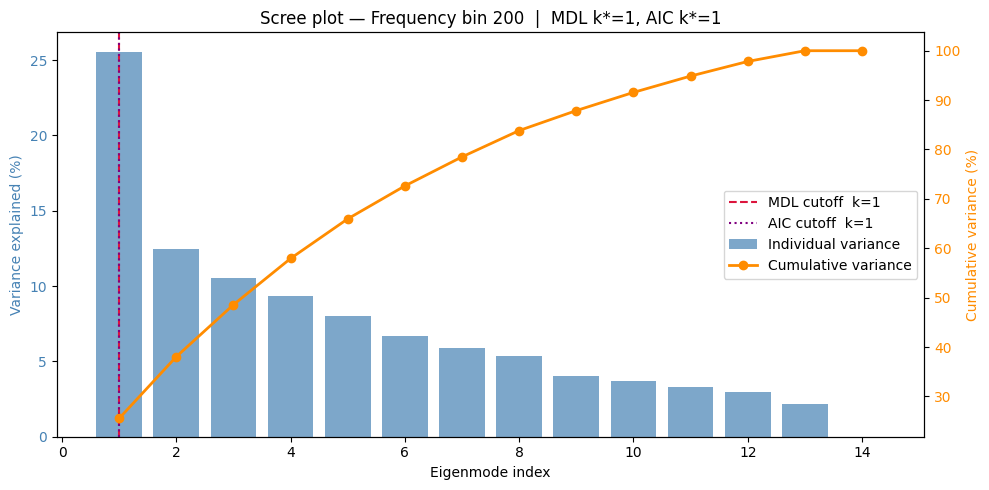

In [9]:
# Scree plot — eigenvalue distribution for a single frequency bin.
# The MDL/AIC cutoffs are now drawn automatically from k_mdl_all / k_aic_all.
# Change bin_index to inspect any of the 513 frequency bins.

bin_index = 200

bin_sqrt_eigs  = desc_sqrt_eigenvalues[bin_index, :n_snapshots]   # top L non-zero
components     = np.arange(1, len(bin_sqrt_eigs) + 1)

variance_explained = (bin_sqrt_eigs / bin_sqrt_eigs.sum()) * 100
cumulative_variance = np.cumsum(variance_explained)

k_mdl_bin = k_mdl_all[bin_index]
k_aic_bin = k_aic_all[bin_index]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(components, variance_explained, color='steelblue', alpha=0.7, label='Individual variance')
ax1.set_xlabel('Eigenmode index')
ax1.set_ylabel('Variance explained (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title(f'Scree plot — Frequency bin {bin_index}  |  MDL k*={k_mdl_bin}, AIC k*={k_aic_bin}')

ax2 = ax1.twinx()
ax2.plot(components, cumulative_variance, color='darkorange', marker='o',
         linewidth=2, label='Cumulative variance')
ax2.set_ylabel('Cumulative variance (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.axvline(x=k_mdl_bin, color='crimson', linestyle='--', linewidth=1.5,
            label=f'MDL cutoff  k={k_mdl_bin}')
ax1.axvline(x=k_aic_bin, color='purple',  linestyle=':',  linewidth=1.5,
            label=f'AIC cutoff  k={k_aic_bin}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

fig.tight_layout()
plt.show()

## Step 3 — Transfer Matrix **A** (SECS)

### Forward Model

$$\mathbf{b} = A\,\mathbf{q}$$

| Symbol | Shape | Meaning |
|--------|-------|---------|
| **b** | (81,) | Observed field — 27 stations × 3 components (X=North, Y=East, Z=Down) |
| **q** | (2K,) | Source amplitudes — K divergence-free + K curl-free elementary current amplitudes |
| **A** | (81, 2K) | SECS transfer matrix |

---

### Physics: Spherical Elementary Current Systems (SECS)

Each basis function is a singular current vortex on the ionospheric shell at altitude $h = 110$ km. The ground-level field from a unit-amplitude pole at angular distance $\theta$ is purely azimuthal around the pole (Amm 1997).

**Divergence-free (DF)** — closed vortex currents:
$$G_\text{DF}(\theta) = \frac{\mu_0}{4\pi R_\text{iono}} \cot\!\frac{\theta}{2}$$

**Curl-free (CF)** — open field-aligned currents:
$$G_\text{CF}(\theta) = -\frac{\mu_0}{4\pi R_\text{iono}} \!\left(\cot\frac{\theta}{2} - \csc\frac{\theta}{2}\right)$$

The field points in the local $\hat{\phi}$ direction (90° clockwise from the azimuth $\alpha$ toward the source pole). Decomposed into the North/East sensor frame:
$$B_X = G(\theta)\sin\alpha, \quad B_Y = -G(\theta)\cos\alpha, \quad B_Z = 0$$

$B_Z = 0$ holds for horizontal sheet currents observed from below the shell.

**Column layout of A:**
- Columns $0 \ldots K{-}1$: DF poles at grid points $0 \ldots K{-}1$
- Columns $K \ldots 2K{-}1$: CF poles at grid points $0 \ldots K{-}1$

**Reference:** Amm, O. (1997). *Ionospheric elementary current systems in spherical coordinates and their application.* J. Geomag. Geoelectr., 49(7), 947–955.

In [10]:
# -- Step 3a: Station Coordinates + SECS Physical Constants ------------------
#
# SECS works in spherical geometry on the globe, so only geographic lat/lon
# (in radians) are needed -- no ECEF conversion required.
#
# Row layout of A:
#   rows 3i, 3i+1, 3i+2  =  X (North), Y (East), Z (Down)  for station i

import matplotlib.gridspec as gridspec

MU0      = 4e-7 * np.pi    # H/m
R_EARTH  = 6371.0e3        # m
IONO_ALT = 110.0e3         # m  -- ionospheric E-layer current shell
R_IONO   = R_EARTH + IONO_ALT

STATIONS = [
    ('MCQ', -54.50, 158.95),
    ('KAT', -33.68, 117.62),
    ('ADL', -34.67, 138.65),
    ('CAN', -35.30, 149.00),
    ('DLB', -27.18, 151.20),
    ('BRV', -25.54, 139.21),
    ('LEM', -22.22, 114.10),
    ('DRW', -12.40, 130.90),
    ('JIC', -12.00, 283.10),
    ('MUT',  14.37, 121.02),
    ('GAM',  13.58, 144.87),
    ('THJ',  24.00, 102.70),
    ('LNP',  25.00, 121.17),
    ('CBI',  27.15, 142.30),
    ('KAG',  31.48, 130.72),
    ('EWA',  21.32, 202.00),
    ('BJI',  40.06, 116.18),
    ('TEO',  19.70, 260.80),
    ('ONW',  38.43, 141.47),
    ('YCB',  38.50, 106.30),
    ('RIK',  43.50, 143.80),
    ('KSH',  39.50,  76.00),
    ('MSR',  44.37, 142.27),
    ('MZL',  49.60, 117.40),
    ('PTK',  52.97, 158.25),
    ('MGD',  60.05, 150.73),
    ('ATH',  54.70, 246.70),
]

station_codes = [s[0] for s in STATIONS]
lats          = np.array([s[1] for s in STATIONS])
lons          = np.array([s[2] for s in STATIONS])   # 0-360 E

N_s        = len(STATIONS)    # 29
N_CHANNELS = N_s * 3          # 81

station_lat = np.radians(lats)   # (29,) geographic latitude  in radians
station_lon = np.radians(lons)   # (29,) geographic longitude in radians

assert N_CHANNELS == 81

print(f"Stations     : {N_s}  ({N_CHANNELS} channel rows)")
print(f"Lat range    : {lats.min():.1f} to {lats.max():.1f} deg N")
print(f"Lon range    : {lons.min():.1f} to {lons.max():.1f} deg E")
print(f"R_iono       : {R_IONO/1e3:.1f} km  (Earth + {IONO_ALT/1e3:.0f} km shell)")
print()
print("Row layout in A:")
print(f"  rows 0,1,2   : {station_codes[0]}   (X=North, Y=East, Z=Down)")
print(f"  rows 3,4,5   : {station_codes[1]}   ...")
print(f"  rows 78,79,80: {station_codes[-1]}")

Stations     : 27  (81 channel rows)
Lat range    : -54.5 to 60.0 deg N
Lon range    : 76.0 to 283.1 deg E
R_iono       : 6481.0 km  (Earth + 110 km shell)

Row layout in A:
  rows 0,1,2   : MCQ   (X=North, Y=East, Z=Down)
  rows 3,4,5   : KAT   ...
  rows 78,79,80: ATH


In [12]:
# -- Step 3b: SECS Coordinate Utilities --------------------------------------

def angular_distance(lat1, lon1, lat2, lon2):
    # Great-circle angular distance (radians) via haversine.
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def azimuth(lat1, lon1, lat2, lon2):
    # Forward azimuth from point 1 to point 2 (radians, clockwise from North).
    dlon = lon2 - lon1
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    return np.arctan2(y, x)


# -- Step 3c: SECS Green's Functions -----------------------------------------
#
# Both functions return the azimuthal field amplitude for a 1-A source pole.
# Near theta=0 (sensor directly under the pole) the field diverges -- physical.
# We return zero there and the user should be aware.

def green_df(theta):
    # Divergence-free SECS Green's function (Amm 1997, obs. below shell).
    # G_DF = mu0 / (4*pi*R_iono) * cot(theta/2)
    theta = np.atleast_1d(np.asarray(theta, dtype=float))
    amp   = np.zeros_like(theta)
    safe  = theta > 1e-6
    amp[safe] = (MU0 / (4 * np.pi * R_IONO)) / np.tan(theta[safe] / 2)
    return amp


def green_cf(theta):
    # Curl-free SECS Green's function (Amm 1997, obs. below shell).
    # G_CF = -mu0 / (4*pi*R_iono) * (cot(theta/2) - csc(theta/2))
    # CF produces weaker, opposite-sign fields compared to DF.
    theta = np.atleast_1d(np.asarray(theta, dtype=float))
    amp   = np.zeros_like(theta)
    safe  = theta > 1e-6
    s     = theta[safe]
    amp[safe] = -(MU0 / (4 * np.pi * R_IONO)) * (1/np.tan(s/2) - 1/np.sin(s/2))
    return amp


# -- Step 3d: Transfer Matrix Builder ----------------------------------------
#
# A shape: (N_CHANNELS, 2*K)
#   rows 3i, 3i+1, 3i+2  ->  X (North), Y (East), Z (Down) at station i
#   cols 0..K-1           ->  DF poles at K grid points
#   cols K..2K-1          ->  CF poles at K grid points
# Units: nT per Ampere

def build_transfer_matrix(grid_lat_deg, grid_lon_deg, verbose=True):
    grid_lat = np.radians(np.asarray(grid_lat_deg, dtype=float))
    grid_lon = np.radians(np.asarray(grid_lon_deg, dtype=float))
    K_pts = len(grid_lat)

    A_mat = np.zeros((N_CHANNELS, 2 * K_pts))

    for p in range(K_pts):
        lat_p = grid_lat[p]
        lon_p = grid_lon[p]

        for i in range(N_s):
            lat_i = station_lat[i]
            lon_i = station_lon[i]

            theta = angular_distance(lat_i, lon_i, lat_p, lon_p)
            az    = azimuth(lat_i, lon_i, lat_p, lon_p)

            # phi_hat in local (North, East) frame: 90 deg clockwise from azimuth
            phi_N =  np.sin(az)
            phi_E = -np.cos(az)

            g_df = green_df(np.array([theta]))[0]
            g_cf = green_cf(np.array([theta]))[0]

            row = i * 3
            A_mat[row,     p]         = g_df * phi_N   # X (North), DF
            A_mat[row + 1, p]         = g_df * phi_E   # Y (East),  DF
            A_mat[row + 2, p]         = 0.0            # Z (Down),  zero

            A_mat[row,     K_pts + p] = g_cf * phi_N   # X (North), CF
            A_mat[row + 1, K_pts + p] = g_cf * phi_E   # Y (East),  CF
            A_mat[row + 2, K_pts + p] = 0.0            # Z (Down),  zero

    A_mat *= 1e9   # T/A -> nT/A

    if verbose:
        print(f"=== SECS Transfer Matrix ===")
        print(f"Stations      : {N_s}  ({N_CHANNELS} rows)")
        print(f"Grid points K : {K_pts}")
        print(f"A shape       : {A_mat.shape}  ({N_CHANNELS} x 2x{K_pts})")
        print(f"  cols 0..{K_pts-1}    : DF (divergence-free)")
        print(f"  cols {K_pts}..{2*K_pts-1} : CF (curl-free)")
        print(f"Units         : nT per Ampere")
        print(f"A max|value|  : {np.abs(A_mat).max():.4e} nT/A")
        nz = A_mat[A_mat != 0]
        print(f"A min|nonzero|: {np.abs(nz).min():.4e} nT/A")
        status = 'under' if 2*K_pts > N_CHANNELS else 'over'
        print(f"System        : {status}determined ({N_CHANNELS} eqs, {2*K_pts} unknowns)")

    return A_mat


# -- Step 3e: Define Source Grid ---------------------------------------------
#
# 2-D geographic lat/lon grid on the ionospheric shell (single altitude R_IONO).
# Covers the station footprint (-55 to +72 lat, 76 to 284 lon) with margin.
# Resolution: 5 deg lat x 10 deg lon.

grid_lat_1d = np.arange(-60,  75, 5)    # 27 pts
grid_lon_1d = np.arange( 70, 290, 10)   # 22 pts

grid_lat_2d, grid_lon_2d = np.meshgrid(grid_lat_1d, grid_lon_1d, indexing='ij')
grid_lat_flat = grid_lat_2d.flatten()   # (K,)
grid_lon_flat = grid_lon_2d.flatten()   # (K,)

n_lat_pts = len(grid_lat_1d)   # 27
n_lon_pts = len(grid_lon_1d)   # 22
K = n_lat_pts * n_lon_pts      # 594  (2*K = 1188 unknowns)

print(f"Source grid : {n_lat_pts} lat x {n_lon_pts} lon = {K} poles")
print(f"Unknowns    : 2 x {K} = {2*K}  (DF + CF)")

# -- Step 3f: Build the Matrix -----------------------------------------------

A = build_transfer_matrix(grid_lat_flat, grid_lon_flat)

# -- Step 3g: Validation -----------------------------------------------------

print("\n=== Validation ===")

assert A.shape == (N_CHANNELS, 2*K), f"Shape mismatch: {A.shape}"
print(f"[PASS] Shape: {A.shape}")

assert np.all(np.isfinite(A)), "NaN or Inf in A"
print("[PASS] No NaN or Inf values")

z_rows = A[2::3, :]
assert np.all(z_rows == 0.0), "Z-component rows should be zero"
print("[PASS] Z-component rows exactly zero (horizontal currents)")

df_cols = A[:, :K]
cf_cols = A[:, K:]
df_norm = np.linalg.norm(df_cols)
cf_norm = np.linalg.norm(cf_cols)
assert cf_norm < df_norm, "CF columns should have smaller norm than DF"
print(f"[PASS] DF norm ({df_norm:.2e}) > CF norm ({cf_norm:.2e}) nT/A")

sv       = np.linalg.svd(A, compute_uv=False)
sv_nz    = sv[sv > sv[0] * 1e-12]          # drop numerical zeros
cond     = sv_nz[0] / sv_nz[-1] if len(sv_nz) > 1 else float("inf")
eff_rank = int(np.sum(sv > sv[0] * 1e-6))
print(f"Singular value range : {sv_nz[-1]:.3e} to {sv_nz[0]:.3e} nT/A")
print(f"Condition number     : {cond:.3e}  (nonzero sv only)")
print(f"Effective rank       : {eff_rank} / {len(sv)}")

# -- Step 3h: Diagnostic Plots -----------------------------------------------

fig = plt.figure(figsize=(16, 11))
fig.suptitle("SECS Transfer Matrix -- Diagnostic Dashboard",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.36)

# Panel A: station + grid map
ax_map = fig.add_subplot(gs[0, :2])
ax_map.scatter(grid_lon_flat, grid_lat_flat,
               c='lightsteelblue', s=8, label='Source grid', zorder=1)
ax_map.scatter(lons, lats, c='crimson', s=60, zorder=3,
               label='Magnetometers', marker='^')
for s in STATIONS:
    ax_map.annotate(s[0], (s[2], s[1]), textcoords='offset points',
                    xytext=(3, 3), fontsize=6, color='crimson')
ax_map.set_xlabel('Geographic longitude (deg)')
ax_map.set_ylabel('Geographic latitude (deg)')
ax_map.set_title(f'Network geometry: {N_s} stations, {K} grid points')
ax_map.legend(fontsize=8)
ax_map.grid(True, alpha=0.3)

# Panel B: DF column norm heatmap (sensitivity map)
ax_norm = fig.add_subplot(gs[0, 2])
col_norms_df = np.linalg.norm(df_cols, axis=0)   # (K,)
norm_grid    = col_norms_df.reshape(n_lat_pts, n_lon_pts)
im = ax_norm.imshow(norm_grid, origin='lower', aspect='auto', cmap='viridis',
                    extent=[grid_lon_1d[0], grid_lon_1d[-1],
                            grid_lat_1d[0], grid_lat_1d[-1]])
ax_norm.scatter(lons, lats, c='white', s=30, marker='^', zorder=3)
plt.colorbar(im, ax=ax_norm, label='Column norm (nT/A)')
ax_norm.set_xlabel('Longitude (deg)')
ax_norm.set_ylabel('Latitude (deg)')
ax_norm.set_title('DF column norms\n(sensitivity map)')

# Panel C: field pattern at all stations for a central DF pole
ax_col = fig.add_subplot(gs[1, 0])
centre_idx = int(np.argmin((grid_lat_flat - 20)**2 + (grid_lon_flat - 140)**2))
col_df = A[:, centre_idx]
x_rows = col_df[0::3]
y_rows = col_df[1::3]
ax_col.barh(np.arange(N_s) - 0.2, x_rows, height=0.4,
            color='steelblue', label='X (North) DF')
ax_col.barh(np.arange(N_s) + 0.2, y_rows, height=0.4,
            color='darkorange', label='Y (East) DF')
ax_col.set_yticks(range(N_s))
ax_col.set_yticklabels(station_codes, fontsize=6)
ax_col.set_xlabel('Field (nT/A)')
ax_col.set_title(f'DF column at grid pt {centre_idx}\n'
                 f'(lat={grid_lat_flat[centre_idx]:.0f} deg, '
                 f'lon={grid_lon_flat[centre_idx]:.0f} deg)')
ax_col.legend(fontsize=7)
ax_col.axvline(0, color='k', lw=0.7)
ax_col.grid(True, alpha=0.3, axis='x')

# Panel D: DF vs CF for same source point
ax_cmp = fig.add_subplot(gs[1, 1])
col_cf = A[:, K + centre_idx]
x_cf   = col_cf[0::3]
y_cf   = col_cf[1::3]
ax_cmp.scatter(x_rows, x_cf, s=20, color='steelblue', label='X (North)', alpha=0.8)
ax_cmp.scatter(y_rows, y_cf, s=20, color='darkorange', label='Y (East)', alpha=0.8)
ax_cmp.axhline(0, color='k', lw=0.5)
ax_cmp.axvline(0, color='k', lw=0.5)
ax_cmp.set_xlabel('DF field (nT/A)')
ax_cmp.set_ylabel('CF field (nT/A)')
ax_cmp.set_title('DF vs CF field at each station\n(same source grid point)')
ax_cmp.legend(fontsize=7)
ax_cmp.grid(True, alpha=0.3)

# Panel E: singular value spectrum
ax_sv = fig.add_subplot(gs[1, 2])
ax_sv.semilogy(sv, 'o-', color='steelblue', ms=4, lw=1.5)
ax_sv.axhline(sv[0] * 1e-6, color='crimson', ls='--', lw=1.5,
              label='Threshold (sigma_max x 1e-6)')
ax_sv.set_xlabel('Singular value index')
ax_sv.set_ylabel('Singular value (log scale)')
ax_sv.set_title('Singular value spectrum of A\n(condition number diagnostic)')
ax_sv.legend(fontsize=7)
ax_sv.grid(True, alpha=0.3, which='both')

fig.set_constrained_layout(True)
plt.show()
print("\nA passed all checks -- ready for ridge regression.")

Source grid : 27 lat x 22 lon = 594 poles
Unknowns    : 2 x 594 = 1188  (DF + CF)
=== SECS Transfer Matrix ===
Stations      : 27  (81 rows)
Grid points K : 594
A shape       : (81, 1188)  (81 x 2x594)
  cols 0..593    : DF (divergence-free)
  cols 594..1187 : CF (curl-free)
Units         : nT per Ampere
A max|value|  : 4.7619e-03 nT/A
A min|nonzero|: 1.8584e-10 nT/A
System        : underdetermined (81 eqs, 1188 unknowns)

=== Validation ===
[PASS] Shape: (81, 1188)
[PASS] No NaN or Inf values
[PASS] Z-component rows exactly zero (horizontal currents)
[PASS] DF norm (9.77e-03) > CF norm (7.87e-04) nT/A
Singular value range : 4.448e-05 to 4.930e-03 nT/A
Condition number     : 1.108e+02  (nonzero sv only)
Effective rank       : 54 / 81


ZeroDivisionError: float division by zero

<Figure size 1600x1100 with 6 Axes>


A passed all checks -- ready for ridge regression.


In [ ]:
# Ridge regression -- solve A q = b for each eigenmode at each frequency bin
#
# A shape: (87, 2*K)  -- SECS transfer matrix in nT/A
# coherent_eigenmodes: (n_freqs, 87, n_modes) -- scaled eigenvectors (nT)
# Q_blurry: (n_freqs, 2*K, n_modes) -- recovered current amplitudes (A), complex

alpha = 0.1   # ridge regularisation -- tune as needed

n_freqs, n_channels, n_modes = coherent_eigenmodes.shape
n_features = A.shape[1]   # 2*K  (K DF + K CF columns)

Q_blurry = np.zeros((n_freqs, n_features, n_modes), dtype=complex)

# Pre-compute Cholesky factorisation -- depends only on A and alpha
ATA        = A.T @ A
reg_matrix = ATA + alpha * np.eye(n_features)
L          = np.linalg.cholesky(reg_matrix)
LT         = L.T

for f in range(n_freqs):
    b_batch = coherent_eigenmodes[f, :, :]    # (87, n_modes)
    ATb     = A.T @ b_batch
    y       = np.linalg.solve(L, ATb)
    Q_blurry[f, :, :] = np.linalg.solve(LT, y)

print("Q_blurry shape:", Q_blurry.shape)
print(f"  (n_freqs={n_freqs}, 2*K={n_features}, n_modes={n_modes})")

In [ ]:
# Create the blurry source map
#
# SECS column layout: cols 0..K-1 = DF, cols K..2K-1 = CF
# Reshape Q_blurry -> (n_freqs, n_lat_pts, n_lon_pts, 2, n_modes)
#   axis 3, size 2: index 0 = DF, index 1 = CF

n_freqs, n_features, n_modes = Q_blurry.shape

Q_blurry_reshaped = Q_blurry.reshape(n_freqs, n_lat_pts, n_lon_pts, 2, n_modes)

# Sum power across source type and eigenmodes -> spatial power grid
source_power_blurry = np.sum(np.abs(Q_blurry_reshaped)**2, axis=(3, 4))

print("Q_blurry_reshaped shape:", Q_blurry_reshaped.shape)
print(f"  (n_freqs, n_lat={n_lat_pts}, n_lon={n_lon_pts}, DF/CF=2, n_modes={n_modes})")
print("Source Power Map shape :", source_power_blurry.shape)
print(f"  (n_freqs, K={K})  -- K = {n_lat_pts}x{n_lon_pts} grid points")